# Merlin UK Opportunity Scoring

This notebook creates the Layer 2 opportunity scoring and attraction alignment output for the Merlin UK geographic customer opportunity prototype.

It uses:

- Layer 1 MSOA customer segments from `notebooks/3_clustering.ipynb`
- Public demographic features carried through the segment output
- Curated Merlin attraction metadata from `data/processed/merlin_attraction_data.csv`

## 1. Setup

Define file paths, scoring weights, and shared helper functions.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", None)
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
DATA_OUTPUT_DIR = PROJECT_ROOT / "data" / "output"
DATA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEGMENT_INPUT_PATH = DATA_PROCESSED_DIR / "msoa_layer_1_customer_segments.csv"
SEGMENT_PROFILE_PATH = DATA_PROCESSED_DIR / "msoa_layer_1_segment_profile_summary.csv"
ATTRACTION_INPUT_PATH = DATA_PROCESSED_DIR / "merlin_attraction_data.csv"

OPPORTUNITY_OUTPUT_PATH = DATA_OUTPUT_DIR / "msoa_layer_2_opportunity_scores.csv"
TOP_OPPORTUNITY_OUTPUT_PATH = DATA_OUTPUT_DIR / "msoa_layer_2_top_opportunity_msoas.csv"
KEY_RECOMMENDATION_OUTPUT_PATH = DATA_OUTPUT_DIR / "merlin_key_recommendation_output.csv"

SCORING_WEIGHTS = {
    "market_size_score": 0.40,
    "segment_priority_score": 0.30,
    "recommended_attraction_alignment_score": 0.30,
}
assert abs(sum(SCORING_WEIGHTS.values()) - 1.0) < 1e-9

PALETTE = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9"]

ATTRACTION_ACCESSIBILITY_DECAY_MILES = 50
ANNUAL_PASS_DISTANCE_MILES = 30
CLUSTER_MARKETING_DISTANCE_MILES = 30
CLUSTER_MARKETING_MIN_ATTRACTIONS = 2
SHORT_BREAK_MIN_DISTANCE_MILES = 40
SHORT_BREAK_MAX_DISTANCE_MILES = 110
HIGH_OPPORTUNITY_PERCENTILE_THRESHOLD = 0.70
TOP_OPPORTUNITY_PERCENTILE_THRESHOLD = 0.90
REVENUE_PER_VISITOR_ASSUMPTION_GBP = 33.0
ILLUSTRATIVE_PENETRATION_RATE = 0.01


def percentile_score(series, ascending=True):
    return series.rank(pct=True, ascending=ascending, method="average").astype(float)


def clipped_01(series):
    return pd.Series(series).clip(lower=0, upper=1).astype(float)


def haversine_miles(lat1, lon1, lat2, lon2):
    earth_radius_miles = 3958.7613
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * earth_radius_miles * np.arcsin(np.sqrt(a))

## 2. Load Inputs and QA

Load the Layer 1 segment output and Merlin attraction data. The MSOA file already includes segment labels and the raw count variables needed for opportunity scoring.

In [2]:
msoa = pd.read_csv(SEGMENT_INPUT_PATH, dtype={"geo_code": str})
segment_profile = pd.read_csv(SEGMENT_PROFILE_PATH)
attractions = pd.read_csv(ATTRACTION_INPUT_PATH, encoding="utf-8-sig")

print(f"MSOAs: {msoa.shape[0]:,} rows x {msoa.shape[1]:,} columns")
print(f"Attractions: {attractions.shape[0]:,} rows x {attractions.shape[1]:,} columns")

display(msoa.head())
display(attractions)

MSOAs: 7,264 rows x 28 columns
Attractions: 20 rows x 11 columns


,geo_code,geo_name,country,latitude,longitude,segment_id,segment_label,total_population,children_count_0_14,young_adult_count_15_24,core_family_adult_count_25_44,midlife_adult_count_45_64,older_adult_count_65_plus,total_households,households_with_dependent_children,households_deprived,households_not_deprived,households_no_car_or_van,households_with_car_or_van,residents_social_grade_ab_c1,children_share_0_14,young_adult_share_15_24,core_family_adult_share_25_44,midlife_adult_share_45_64,older_adult_share_65_plus,car_access_household_share,population_density_per_sq_km,ab_c1_social_grade_share
0,E02000001,City of London 001,England,51.51562,-0.093490,0,Dense Urban Professional Markets,8580,546,1181,3488,2159,1206,4916,431,1977,2937,3793,1120,5950,0.063636,0.137646,0.406527,0.251632,0.140559,0.227967,2975.0,0.840514
1,E02000002,Barking and Dagenham 001,England,51.58652,0.138756,2,Balanced Regional Family Markets,8286,2172,1028,2426,1731,929,2871,1350,1916,954,914,1956,2971,0.262129,0.124065,0.292783,0.208907,0.112117,0.681533,3831.0,0.410756
2,E02000003,Barking and Dagenham 002,England,51.57606,0.138149,2,Balanced Regional Family Markets,11539,2560,1451,3653,2604,1271,3931,1660,2281,1649,1156,2774,4756,0.221856,0.125747,0.316579,0.225669,0.110148,0.705852,5389.7,0.473847
3,E02000004,Barking and Dagenham 003,England,51.55639,0.176828,4,Mainstream Affluent Suburban Markets,6638,1238,815,1919,1667,999,2309,835,1295,1014,544,1765,2739,0.186502,0.122778,0.289093,0.251130,0.150497,0.764400,2663.6,0.508069
4,E02000005,Barking and Dagenham 004,England,51.56069,0.144267,2,Balanced Regional Family Markets,11082,2935,1355,3503,2406,883,3627,1804,2086,1544,1016,2612,4628,0.264844,0.122270,0.316098,0.217109,0.079679,0.719956,9327.5,0.461278


,attraction_name_official,brand_official,business_division_official,city_official,postcode_official,latitude,longitude,experience_category_inferred,indoor_outdoor_inferred,target_age_group_inferred,family_friendly_inferred
0,Alton Towers Resort,Alton Towers,Resort Theme Parks,Alton,ST10 4DB,52.985926,-1.887592,Thrill Theme Park,Mixed,children_0_14|young_adults_15_24|core_family_adults_25_44,Yes
1,Thorpe Park,Thorpe Park,Resort Theme Parks,Chertsey,KT16 8PN,51.405100,-0.532991,Thrill Theme Park,Outdoor,young_adults_15_24|core_family_adults_25_44,Yes
2,Chessington World of Adventures Resort,Chessington,Resort Theme Parks,Chessington,KT9 2NE,51.348502,-0.321584,Family Theme Park,Mixed,children_0_14|core_family_adults_25_44,Yes
3,LEGOLAND Windsor Resort,LEGOLAND,Resort Theme Parks,Windsor,SL4 4AY,51.463834,-0.652602,Family Theme Park,Outdoor,children_0_14|core_family_adults_25_44,Yes
4,Warwick Castle,Warwick Castle,Gateway Attractions,Warwick,CV34 6AU,52.279500,-1.584900,Heritage Attraction,Mixed,children_0_14|core_family_adults_25_44|midlife_adults_45_64,Yes
5,London Eye,London Eye,Gateway Attractions,London,SE1 7PB,51.503186,-0.122094,Urban Icon Attraction,Outdoor,all_age_groups,Yes
6,Madame Tussauds London,Madame Tussauds,Gateway Attractions,London,NW1 5LR,51.523005,-0.156988,Urban Icon Attraction,Indoor,all_age_groups,Yes
7,London Dungeon,The Dungeons,Gateway Attractions,London,SE1 7PB,51.502512,-0.121338,Young Adult Immersive,Indoor,young_adults_15_24|core_family_adults_25_44,No
8,Shrek's Adventure! London,Shrek's Adventure!,Gateway Attractions,London,SE1 7PB,51.501882,-0.121948,Family Discovery Attraction,Indoor,children_0_14|core_family_adults_25_44,Yes
9,Cadbury World,Cadbury World,Gateway Attractions,Birmingham,B30 1JR,52.428795,-1.934000,Family Discovery Attraction,Indoor,children_0_14|core_family_adults_25_44|midlife_adults_45_64,Yes


### 2.1 Check missing values

In [3]:
required_msoa_columns = [
    "geo_code", "geo_name", "country", "latitude", "longitude", "segment_id", "segment_label",
    "total_population", "children_count_0_14", "young_adult_count_15_24",
    "core_family_adult_count_25_44", "midlife_adult_count_45_64", "older_adult_count_65_plus",
    "total_households", "households_with_dependent_children", "households_deprived",
    "households_no_car_or_van", "households_with_car_or_van", "residents_social_grade_ab_c1",
    "children_share_0_14", "young_adult_share_15_24", "core_family_adult_share_25_44",
    "midlife_adult_share_45_64", "older_adult_share_65_plus", "car_access_household_share",
    "population_density_per_sq_km", "ab_c1_social_grade_share",
]
required_attraction_columns = [
    "attraction_name_official", "brand_official", "business_division_official", "city_official",
    "latitude", "longitude", "experience_category_inferred", "target_age_group_inferred",
    "family_friendly_inferred",
]

missing_msoa_columns = sorted(set(required_msoa_columns) - set(msoa.columns))
missing_attraction_columns = sorted(set(required_attraction_columns) - set(attractions.columns))
assert not missing_msoa_columns, f"Missing MSOA columns: {missing_msoa_columns}"
assert not missing_attraction_columns, f"Missing attraction columns: {missing_attraction_columns}"
assert msoa["geo_code"].is_unique, "Each MSOA should appear once."
assert msoa[["latitude", "longitude"]].notna().all().all(), "MSOA latitude/longitude cannot be missing."
assert attractions[["latitude", "longitude"]].notna().all().all(), "Attraction latitude/longitude cannot be missing."

msoa[required_msoa_columns].isna().sum().sort_values(ascending=False).head(10)

geo_code                              0
households_with_dependent_children    0
population_density_per_sq_km          0
car_access_household_share            0
older_adult_share_65_plus             0
midlife_adult_share_45_64             0
core_family_adult_share_25_44         0
young_adult_share_15_24               0
children_share_0_14                   0
residents_social_grade_ab_c1          0
dtype: int64

## 3. Feature Engineering for Scoring

Only two MSOA-level scores are needed before the attraction recommendation step:

- `market_size_score`: MSOA population percentile. Larger MSOAs score higher because they offer more addressable demand.
- `segment_priority_score`: business judgement from the Layer 1 segment interpretation. Higher-priority segments score higher because they better match Merlin's strategic customer opportunity.

Other demographic variables are still kept in the output for context and later analysis, but they are not converted into separate opportunity-score components here.

In [4]:
scored = msoa.copy()

# Keep these descriptive shares for export and interpretation, but do not use them as separate score components.
scored["family_household_share"] = scored["households_with_dependent_children"] / scored["total_households"]
scored["deprived_household_share"] = scored["households_deprived"] / scored["total_households"]
scored["not_deprived_household_share"] = 1 - scored["deprived_household_share"]

scored["market_size_score"] = percentile_score(scored["total_population"])

SEGMENT_PRIORITY = {
    "Mainstream Affluent Suburban Markets": 1.00,
    "Balanced Regional Family Markets": 0.80,
    "Dense Urban Professional Markets": 0.60,
    "Older Rural & Low-Density Markets": 0.40,
    "Student & Young Adult Urban Markets": 0.20,
}
scored["segment_priority_score"] = scored["segment_label"].map(SEGMENT_PRIORITY)
assert scored["segment_priority_score"].notna().all(), "Every segment needs a priority score."

pre_recommendation_score_columns = ["market_size_score", "segment_priority_score"]
scored[pre_recommendation_score_columns].describe().round(3)

,market_size_score,segment_priority_score
count,7264.000,7264.000
mean,0.500,0.750
std,0.289,0.256
min,0.000,0.200
25%,0.250,0.400
50%,0.500,0.800
75%,0.750,1.000
max,1.000,1.000


## 4. Merlin Attraction Distance and Alignment

Distances are straight-line centroid-to-attraction distances. They are suitable for a prototype accessibility signal, but they are not drive times. Distances are reported in **miles**, which is the more familiar unit for UK stakeholder discussion.

### 4.1 Explain the Attraction Alignment Score

The attraction recommendation uses a combined `recommended_attraction_alignment_score`. This score is calculated for every MSOA-attraction pair, then the highest-scoring attraction is selected for that MSOA.

The formula is:

```text
recommended_attraction_alignment_score =
    0.70 * segment_category_fit_score
  + 0.30 * attraction_accessibility
```

The two inputs mean:

- `segment_category_fit_score`: how well the attraction category fits the MSOA's customer segment. This comes from the segment-to-category rule table in section 4.3.
- `attraction_accessibility`: how accessible that specific attraction is from the MSOA centroid. This is calculated from straight-line distance in miles:

```text
attraction_accessibility = exp(-distance_to_that_attraction_miles / 50)
```

The 50-mile decay constant is a simple stakeholder-friendly assumption: accessibility reduces gradually as distance increases, without treating a nearby and slightly farther MSOA as completely different. The 70/30 split means the recommendation is mostly driven by customer/proposition fit, but distance still matters when choosing the most practical attraction. This is not a drive-time model; it is a transparent prototype proxy that should be calibrated with travel-time or catchment data if available.

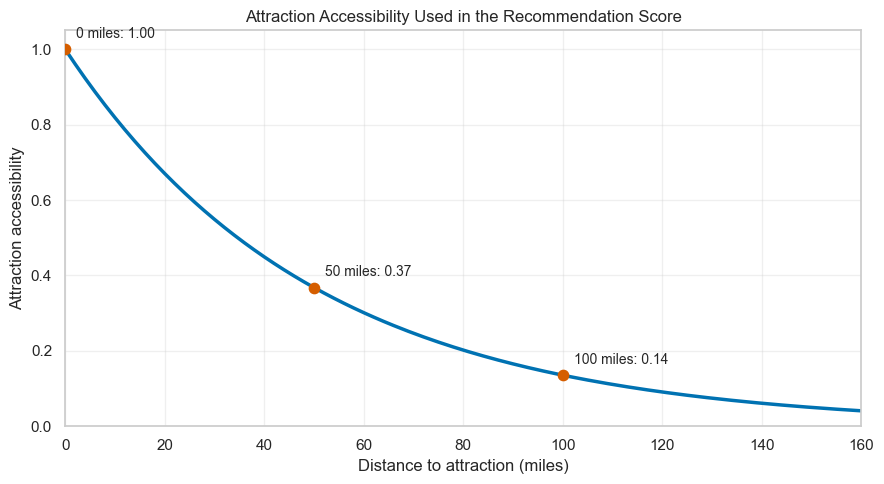

In [5]:
distance_example = pd.DataFrame({"distance_to_attraction_miles": np.linspace(0, 160, 161)})
distance_example["attraction_accessibility"] = np.exp(
    -distance_example["distance_to_attraction_miles"] / ATTRACTION_ACCESSIBILITY_DECAY_MILES
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(
    data=distance_example,
    x="distance_to_attraction_miles",
    y="attraction_accessibility",
    color="#0072B2",
    linewidth=2.5,
    ax=ax,
)

reference_distances = [0, round(ATTRACTION_ACCESSIBILITY_DECAY_MILES), round(2 * ATTRACTION_ACCESSIBILITY_DECAY_MILES)]
for distance in reference_distances:
    score = np.exp(-distance / ATTRACTION_ACCESSIBILITY_DECAY_MILES)
    ax.scatter(distance, score, color="#D55E00", s=55, zorder=3)
    ax.annotate(
        f"{distance} miles: {score:.2f}",
        xy=(distance, score),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10,
    )

ax.set_title("Attraction Accessibility Used in the Recommendation Score")
ax.set_xlabel("Distance to attraction (miles)")
ax.set_ylabel("Attraction accessibility")
ax.set_xlim(0, 160)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.2 Calculate Nearest Merlin Attraction Distance

Calculate straight-line distances from every MSOA centroid to every Merlin attraction. This creates the distance matrix used later for attraction-specific accessibility. We also keep the nearest Merlin attraction overall as a descriptive field for interpretation.

In [6]:
msoa_lat = scored["latitude"].to_numpy()[:, None]
msoa_lon = scored["longitude"].to_numpy()[:, None]
attr_lat = attractions["latitude"].to_numpy()[None, :]
attr_lon = attractions["longitude"].to_numpy()[None, :]

distance_matrix = haversine_miles(msoa_lat, msoa_lon, attr_lat, attr_lon)
nearest_idx = distance_matrix.argmin(axis=1)

scored["nearest_merlin_attraction"] = attractions.iloc[nearest_idx]["attraction_name_official"].to_numpy()
scored["nearest_merlin_brand"] = attractions.iloc[nearest_idx]["brand_official"].to_numpy()
scored["nearest_merlin_category"] = attractions.iloc[nearest_idx]["experience_category_inferred"].to_numpy()
scored["nearest_merlin_distance_miles"] = distance_matrix.min(axis=1).round(1)

for division in attractions["business_division_official"].dropna().unique():
    safe_name = division.lower().replace(" ", "_").replace("/", "_")
    cols = attractions["business_division_official"].eq(division).to_numpy()
    scored[f"nearest_{safe_name}_distance_miles"] = distance_matrix[:, cols].min(axis=1).round(1)

scored[["geo_name", "segment_label", "nearest_merlin_attraction", "nearest_merlin_distance_miles"]].head()

,geo_name,segment_label,nearest_merlin_attraction,nearest_merlin_distance_miles
0,City of London 001,Dense Urban Professional Markets,London Eye,1.5
1,Barking and Dagenham 001,Balanced Regional Family Markets,London Dungeon,12.6
2,Barking and Dagenham 002,Balanced Regional Family Markets,London Dungeon,12.3
3,Barking and Dagenham 003,Mainstream Affluent Suburban Markets,London Dungeon,13.3
4,Barking and Dagenham 004,Balanced Regional Family Markets,London Dungeon,12.1


### 4.3 Segment-Based Attraction Fit and Recommendation

This step recommends a specific Merlin attraction for each MSOA using a simple, explainable process. The recommendation is not based on distance alone, and it is not based on demographics alone. It combines the customer segment fit with attraction accessibility.

The process works as follows:

1. **Start with the MSOA segment.** Each MSOA already has a `segment_label` from Layer 1, such as `Mainstream Affluent Suburban Markets`, `Balanced Regional Family Markets`, or `Student & Young Adult Urban Markets`.

2. **Map that segment to Merlin attraction categories.** The table below assigns a `segment_category_fit_score` between each customer segment and each simplified attraction category from `merlin_attraction_data.csv`. A score of `1.00` means the category is a very strong fit for that segment. Lower scores mean the category is still possible, but less central to the segment proposition.

3. **Score every Merlin attraction for that MSOA.** Each attraction inherits the segment/category fit score for its category. For example, if an MSOA is in `Balanced Regional Family Markets`, then attractions in `Family Discovery Attraction` receive a high fit score because that category is a strong family proposition.

4. **Calculate attraction-specific accessibility.** For each MSOA-attraction pair, calculate `attraction_accessibility` from the straight-line distance to that specific attraction using the distance-decay formula in section 4.1.

5. **Combine fit and accessibility.** For each MSOA-attraction pair, calculate `recommended_attraction_alignment_score` using the 70/30 formula in section 4.1.

6. **Pick the highest-scoring attraction.** The attraction with the highest `recommended_attraction_alignment_score` becomes the `recommended_attraction_name` for that MSOA.

The output fields mean:

- `recommended_attraction_name`: the Merlin attraction with the best combined fit and accessibility score.
- `recommended_attraction_category`: the simplified proposition category of that attraction.
- `recommended_attraction_distance_miles`: straight-line distance from the MSOA centroid to the recommended attraction, reported in miles.
- `segment_category_fit_score`: the segment/category fit score of the recommended attraction only.
- `recommended_attraction_alignment_score`: the final combined score used to choose the recommended attraction and to feed into the overall opportunity score.

In short: **the segment decides what kind of Merlin proposition fits; distance helps choose the most practical attraction within that proposition.**

In [7]:
SEGMENT_ATTRACTION_CATEGORY_FIT = {
    "Mainstream Affluent Suburban Markets": {
        "Family Theme Park": 1.00,
        "Family Discovery Attraction": 0.95,
        "Thrill Theme Park": 0.80,
        "Heritage Attraction": 0.75,
        "Urban Icon Attraction": 0.65,
        "Young Adult Immersive": 0.50,
    },
    "Balanced Regional Family Markets": {
        "Family Discovery Attraction": 1.00,
        "Family Theme Park": 0.90,
        "Heritage Attraction": 0.75,
        "Thrill Theme Park": 0.65,
        "Urban Icon Attraction": 0.60,
        "Young Adult Immersive": 0.45,
    },
    "Dense Urban Professional Markets": {
        "Urban Icon Attraction": 1.00,
        "Young Adult Immersive": 0.85,
        "Family Discovery Attraction": 0.75,
        "Thrill Theme Park": 0.65,
        "Heritage Attraction": 0.55,
        "Family Theme Park": 0.50,
    },
    "Student & Young Adult Urban Markets": {
        "Young Adult Immersive": 1.00,
        "Thrill Theme Park": 0.90,
        "Urban Icon Attraction": 0.80,
        "Family Discovery Attraction": 0.55,
        "Family Theme Park": 0.45,
        "Heritage Attraction": 0.35,
    },
    "Older Rural & Low-Density Markets": {
        "Heritage Attraction": 1.00,
        "Family Discovery Attraction": 0.80,
        "Family Theme Park": 0.70,
        "Urban Icon Attraction": 0.55,
        "Thrill Theme Park": 0.45,
        "Young Adult Immersive": 0.30,
    },
}

attraction_categories = attractions["experience_category_inferred"].tolist()
category_fit_matrix = np.array(
    [
        [SEGMENT_ATTRACTION_CATEGORY_FIT[segment].get(category, 0.25) for category in attraction_categories]
        for segment in scored["segment_label"]
    ]
)

attraction_accessibility_matrix = np.clip(np.exp(-distance_matrix / ATTRACTION_ACCESSIBILITY_DECAY_MILES), 0, 1)
alignment_matrix = np.clip(0.70 * category_fit_matrix + 0.30 * attraction_accessibility_matrix, 0, 1)
best_alignment_idx = alignment_matrix.argmax(axis=1)

scored["segment_category_fit_score"] = category_fit_matrix[np.arange(len(scored)), best_alignment_idx]
scored["recommended_attraction_name"] = attractions.iloc[best_alignment_idx]["attraction_name_official"].to_numpy()
scored["recommended_attraction_brand"] = attractions.iloc[best_alignment_idx]["brand_official"].to_numpy()
scored["recommended_attraction_category"] = attractions.iloc[best_alignment_idx]["experience_category_inferred"].to_numpy()
scored["recommended_attraction_distance_miles"] = distance_matrix[np.arange(len(scored)), best_alignment_idx].round(1)
scored["recommended_attraction_alignment_score"] = alignment_matrix.max(axis=1)
scored["recommended_attraction_focus"] = scored["recommended_attraction_brand"] + " - " + scored["recommended_attraction_category"]

segment_category_fit_table = pd.DataFrame(SEGMENT_ATTRACTION_CATEGORY_FIT).T[attractions["experience_category_inferred"].drop_duplicates().sort_values()]
display(segment_category_fit_table)

scored[[
    "geo_name",
    "segment_label",
    "recommended_attraction_name",
    "recommended_attraction_category",
    "recommended_attraction_distance_miles",
    "segment_category_fit_score",
    "recommended_attraction_alignment_score",
]].head()

,Family Discovery Attraction,Family Theme Park,Heritage Attraction,Thrill Theme Park,Urban Icon Attraction,Young Adult Immersive
Mainstream Affluent Suburban Markets,0.95,1.00,0.75,0.80,0.65,0.50
Balanced Regional Family Markets,1.00,0.90,0.75,0.65,0.60,0.45
Dense Urban Professional Markets,0.75,0.50,0.55,0.65,1.00,0.85
Student & Young Adult Urban Markets,0.55,0.45,0.35,0.90,0.80,1.00
Older Rural & Low-Density Markets,0.80,0.70,1.00,0.45,0.55,0.30


,geo_name,segment_label,recommended_attraction_name,recommended_attraction_category,recommended_attraction_distance_miles,segment_category_fit_score,recommended_attraction_alignment_score
0,City of London 001,Dense Urban Professional Markets,London Eye,Urban Icon Attraction,1.5,1.00,0.991132
1,Barking and Dagenham 001,Balanced Regional Family Markets,Shrek's Adventure! London,Family Discovery Attraction,12.6,1.00,0.933001
2,Barking and Dagenham 002,Balanced Regional Family Markets,Shrek's Adventure! London,Family Discovery Attraction,12.3,1.00,0.934592
3,Barking and Dagenham 003,Mainstream Affluent Suburban Markets,Shrek's Adventure! London,Family Discovery Attraction,13.4,0.95,0.894548
4,Barking and Dagenham 004,Balanced Regional Family Markets,Shrek's Adventure! London,Family Discovery Attraction,12.1,1.00,0.935317


## 5. Overall Opportunity Score

The overall score is intentionally simple and presentation-friendly. It combines three signals:

1. **Market scale**: is the local population large enough to matter?
2. **Customer segment priority**: is this the type of market Merlin wants to prioritise?
3. **Merlin proposition alignment**: is there a relevant and reasonably accessible Merlin attraction proposition for this MSOA?

The formula is:

```text
overall_opportunity_score =
    0.40 * market_size_score
  + 0.30 * segment_priority_score
  + 0.30 * recommended_attraction_alignment_score
```

The result is multiplied by 100 so the final score is easier to read on a 0-100 scale. The output is kept as a continuous score, rank and percentile. I do not create separate categorical priority labels because that would introduce an unnecessary second segmentation layer.

### 5.1 Calculate and Review Overall Opportunity Score

In [8]:
score_columns = list(SCORING_WEIGHTS.keys())
scored["overall_opportunity_score"] = 0.0
for column, weight in SCORING_WEIGHTS.items():
    scored["overall_opportunity_score"] += weight * scored[column]

scored["overall_opportunity_score"] = (100 * scored["overall_opportunity_score"]).round(1)
scored["opportunity_rank"] = scored["overall_opportunity_score"].rank(ascending=False, method="first").astype(int)
scored["opportunity_percentile"] = 1 - ((scored["opportunity_rank"] - 1) / (len(scored) - 1))

scored[["overall_opportunity_score", "opportunity_rank", "opportunity_percentile"] + score_columns].describe().round(2)

,overall_opportunity_score,opportunity_rank,opportunity_percentile,market_size_score,segment_priority_score,recommended_attraction_alignment_score
count,7264.0,7264.00,7264.00,7264.00,7264.00,7264.00
mean,67.7,3632.50,0.50,0.50,0.75,0.84
std,15.1,2097.08,0.29,0.29,0.26,0.08
min,29.4,1.00,0.00,0.00,0.20,0.70
25%,57.4,1816.75,0.25,0.25,0.40,0.77
50%,68.3,3632.50,0.50,0.50,0.80,0.83
75%,79.7,5448.25,0.75,0.75,1.00,0.91
max,97.7,7264.00,1.00,1.00,1.00,1.00


### 5.2 Add Activation and Driver Explanations

In [9]:
def key_contributing_driver(row):
    labels = {
        "market_size_score": "large local market",
        "segment_priority_score": "priority customer segment",
        "recommended_attraction_alignment_score": "strong Merlin proposition alignment",
    }
    weighted_contributions = {
        column: row[column] * SCORING_WEIGHTS[column]
        for column in score_columns
    }
    top_component = max(weighted_contributions, key=weighted_contributions.get)
    return labels[top_component]


scored["key_contributing_driver"] = scored.apply(key_contributing_driver, axis=1)
scored["assumptions_flag"] = "Straight-line distance proxy in miles; judgement-based weights; attraction coordinates and simplified categories are maintained in merlin_attraction_data.csv."

scored.sort_values("opportunity_rank").head(10)[[
    "opportunity_rank", "geo_name", "country", "segment_label", "overall_opportunity_score",
    "recommended_attraction_name", "recommended_attraction_distance_miles", "key_contributing_driver",
]]

,opportunity_rank,geo_name,country,segment_label,overall_opportunity_score,recommended_attraction_name,recommended_attraction_distance_miles,key_contributing_driver
3203,1,Bracknell Forest 002,England,Mainstream Affluent Suburban Markets,97.7,LEGOLAND Windsor Resort,5.1,large local market
569,2,Kingston upon Thames 004,England,Mainstream Affluent Suburban Markets,97.6,Chessington World of Adventures Resort,4.8,large local market
6585,3,Epsom and Ewell 010,England,Mainstream Affluent Suburban Markets,97.6,Chessington World of Adventures Resort,3.6,large local market
3298,4,Wokingham 012,England,Mainstream Affluent Suburban Markets,97.5,LEGOLAND Windsor Resort,12.7,large local market
6154,5,Runnymede 007,England,Mainstream Affluent Suburban Markets,97.5,Chessington World of Adventures Resort,8.0,large local market
6628,6,Harrow 033,England,Mainstream Affluent Suburban Markets,97.3,Chessington World of Adventures Resort,16.8,large local market
6668,7,Redbridge 036,England,Mainstream Affluent Suburban Markets,97.3,Shrek's Adventure! London,9.4,large local market
741,8,Richmond upon Thames 004,England,Mainstream Affluent Suburban Markets,97.2,Chessington World of Adventures Resort,8.4,large local market
3529,9,Buckinghamshire 053,England,Mainstream Affluent Suburban Markets,97.1,LEGOLAND Windsor Resort,10.0,large local market
5001,10,Fylde 002,England,Mainstream Affluent Suburban Markets,96.9,SEA LIFE Blackpool,6.7,large local market


### 5.3 Commercial Activation Plays

The opportunity score ranks where Merlin should focus. This step translates that ranking into a simple commercial recommendation that is easier for senior stakeholders to act on.

The output deliberately uses a small number of activation plays, so it does not become a second segmentation model:

- **Annual Pass**: high-opportunity MSOAs within 30 miles of the recommended attraction. This identifies local catchments where repeat visitation and pass value are easiest to communicate.
- **Multi-Attraction Cluster Marketing**: high-opportunity MSOAs within 30 miles of at least two distinct Merlin attractions. This supports cross-sell, bundled messaging, and annual-pass propositions across nearby attractions.
- **Short Break**: high-opportunity family/affluent MSOAs that are 40-110 miles from the recommended attraction. This uses a simple overnight-trip distance band: far enough for a short break to make sense, but not so far that the journey becomes unrealistic for most households.
- **Other**: all remaining MSOAs. These are retained in the dataset for completeness, but they are not assigned a specific strategic activation play from this simple ruleset.
- **Illustrative Revenue Opportunity**: a conservative scenario, not a forecast. It uses Merlin annual-report revenue per visitor of about GBP33, a 1% illustrative penetration rate, and the opportunity score as a weighting factor.

High opportunity is defined by `opportunity_percentile >= 0.70`, i.e. the top 30% of MSOAs by score. The top 10% is used only for summary views, not as a new segment label.

Formula:

`illustrative_revenue_opportunity_1pct_gbp = total_population * 1% * GBP33 * (overall_opportunity_score / 100)`

This is useful for comparing relative scale across markets, but it should be calibrated with internal ticket yield, visitor penetration, passholder, accommodation, retail, and food-and-beverage data before being used as a financial forecast.

In [10]:
RESORT_OR_DESTINATION_CATEGORIES = [
    "Family Theme Park",
    "Thrill Theme Park",
    "Heritage Attraction",
]

scored["top_10_opportunity_flag"] = scored["opportunity_percentile"] >= TOP_OPPORTUNITY_PERCENTILE_THRESHOLD
scored["top_10_opportunity_population"] = np.where(scored["top_10_opportunity_flag"], scored["total_population"], 0)

within_cluster_distance = distance_matrix <= CLUSTER_MARKETING_DISTANCE_MILES
scored["merlin_attractions_within_30_miles"] = within_cluster_distance.sum(axis=1).astype(int)

attraction_names = attractions["attraction_name_official"].to_numpy()
scored["merlin_attraction_cluster_names_30_miles"] = [
    "; ".join(attraction_names[row]) if row.any() else "None within 30 miles"
    for row in within_cluster_distance
]

high_opportunity_mask = scored["opportunity_percentile"] >= HIGH_OPPORTUNITY_PERCENTILE_THRESHOLD
family_affluent_mask = (
    (scored["family_household_share"] >= scored["family_household_share"].median())
    & (scored["ab_c1_social_grade_share"] >= scored["ab_c1_social_grade_share"].median())
)
resort_or_destination_mask = scored["recommended_attraction_category"].isin(RESORT_OR_DESTINATION_CATEGORIES)

scored["annual_pass_repeat_visit_flag"] = (
    high_opportunity_mask
    & (scored["recommended_attraction_distance_miles"] <= ANNUAL_PASS_DISTANCE_MILES)
)
scored["cluster_marketing_flag"] = (
    high_opportunity_mask
    & (scored["merlin_attractions_within_30_miles"] >= CLUSTER_MARKETING_MIN_ATTRACTIONS)
)
scored["short_break_opportunity_flag"] = (
    high_opportunity_mask
    & family_affluent_mask
    & resort_or_destination_mask
    & scored["recommended_attraction_distance_miles"].between(SHORT_BREAK_MIN_DISTANCE_MILES, SHORT_BREAK_MAX_DISTANCE_MILES)
)


def recommended_commercial_play(row):
    if row["cluster_marketing_flag"]:
        return "Multi-attraction cluster marketing"
    if row["annual_pass_repeat_visit_flag"]:
        return "Annual pass"
    if row["short_break_opportunity_flag"]:
        return "Short break"
    return "Other"


def commercial_play_rationale(row):
    if row["recommended_commercial_play"] == "Multi-attraction cluster marketing":
        return f"High-opportunity MSOA with {row['merlin_attractions_within_30_miles']} Merlin attractions within 30 miles."
    if row["recommended_commercial_play"] == "Annual pass":
        return "High-opportunity MSOA within 30 miles of the recommended attraction."
    if row["recommended_commercial_play"] == "Short break":
        return "High-opportunity family/affluent MSOA at a practical overnight-trip distance."
    return "MSOA does not meet the simple rules for cluster marketing, annual pass, or short-break activation."


def recommended_activation(row):
    play = row["recommended_commercial_play"]
    if play == "Multi-attraction cluster marketing":
        return "Promote annual pass, multi-attraction bundles, CRM cross-sell and local cluster campaigns."
    if play == "Annual pass":
        return "Promote annual pass value, repeat-visit benefits and in-attraction upsell opportunities."
    if play == "Short break":
        return "Promote short-break packages, overnight stays and family premium occasions."
    return "Retain for broader seasonal, local, or tactical activity rather than a specific strategic play."


scored["recommended_commercial_play"] = scored.apply(recommended_commercial_play, axis=1)
scored["commercial_play_rationale"] = scored.apply(commercial_play_rationale, axis=1)
scored["recommended_activation"] = scored.apply(recommended_activation, axis=1)

# Keep the original output column name, but make it rule-based rather than segment-only.
scored["recommended_product_focus"] = scored["recommended_commercial_play"]

scored["revenue_per_visitor_assumption_gbp"] = REVENUE_PER_VISITOR_ASSUMPTION_GBP
scored["penetration_rate_assumption"] = ILLUSTRATIVE_PENETRATION_RATE
scored["illustrative_revenue_opportunity_1pct_gbp"] = (
    scored["total_population"]
    * ILLUSTRATIVE_PENETRATION_RATE
    * REVENUE_PER_VISITOR_ASSUMPTION_GBP
    * (scored["overall_opportunity_score"] / 100)
).round(0).astype(int)

commercial_play_summary = (
    scored.groupby("recommended_commercial_play", as_index=False)
    .agg(
        msoa_count=("geo_code", "count"),
        top_10_msoas=("top_10_opportunity_flag", "sum"),
        total_population=("total_population", "sum"),
        illustrative_revenue_opportunity_1pct_gbp=("illustrative_revenue_opportunity_1pct_gbp", "sum"),
        mean_opportunity_score=("overall_opportunity_score", "mean"),
    )
    .sort_values(["top_10_msoas", "illustrative_revenue_opportunity_1pct_gbp"], ascending=[False, False])
)

commercial_play_summary.round(1)

,recommended_commercial_play,msoa_count,top_10_msoas,total_population,illustrative_revenue_opportunity_1pct_gbp,mean_opportunity_score
1,Multi-attraction cluster marketing,1072,365,10649026,3015258,85.3
2,Other,5823,220,45325197,9776905,63.3
0,Annual pass,296,107,2868913,813784,85.4
3,Short break,73,35,754227,218702,87.3


## 6. Business Insights and Activation Priorities

This section translates the MSOA-level opportunity output into the points needed for the business insights and activation slide:

- which customer segments create the strongest opportunity
- which local authority areas contain the highest concentration of top-ranked MSOAs
- which Merlin propositions are most naturally aligned to those areas
- how media and commercial activation should differ by segment and attraction focus

### 6.1 Which Customer Segments Create the Strongest Opportunity?

In [11]:
scored["area_name"] = scored["geo_name"].str.replace(r"\s+\d+$", "", regex=True)


def mode_or_none(series):
    modes = series.dropna().mode()
    return modes.iat[0] if not modes.empty else "None"


def top_area_examples(group, n=5):
    areas = group.loc[group["top_10_opportunity_flag"], "area_name"].value_counts().head(n).index.tolist()
    return ", ".join(areas) if areas else "No top-10% MSOAs"

segment_base_summary = (
    scored.groupby(["segment_id", "segment_label"], as_index=False)
    .agg(
        msoa_count=("geo_code", "count"),
        total_population=("total_population", "sum"),
        mean_opportunity_score=("overall_opportunity_score", "mean"),
        median_opportunity_score=("overall_opportunity_score", "median"),
        top_10_msoas=("top_10_opportunity_flag", "sum"),
        top_10_population=("top_10_opportunity_population", "sum"),
        mean_recommended_distance_miles=("recommended_attraction_distance_miles", "mean"),
        main_commercial_play=("recommended_commercial_play", mode_or_none),
        main_recommended_focus=("recommended_attraction_focus", mode_or_none),
    )
)

segment_area_examples = (
    scored.groupby(["segment_id", "segment_label"])
    .apply(top_area_examples)
    .rename("top_10_area_examples")
    .reset_index()
)

segment_opportunity_summary = (
    segment_base_summary.merge(segment_area_examples, on=["segment_id", "segment_label"], how="left")
    .assign(
        top_10_share=lambda df: df["top_10_msoas"] / df["msoa_count"],
        population_millions=lambda df: df["total_population"] / 1_000_000,
        top_10_population_millions=lambda df: df["top_10_population"] / 1_000_000,
    )
    .sort_values(["top_10_msoas", "mean_opportunity_score"], ascending=[False, False])
)

segment_display_cols = [
    "segment_label",
    "msoa_count",
    "population_millions",
    "mean_opportunity_score",
    "top_10_msoas",
    "top_10_share",
    "top_10_population_millions",
    "mean_recommended_distance_miles",
    "main_commercial_play",
    "top_10_area_examples",
]

segment_opportunity_summary[segment_display_cols].round(3)

,segment_label,msoa_count,population_millions,mean_opportunity_score,top_10_msoas,top_10_share,top_10_population_millions,mean_recommended_distance_miles,main_commercial_play,top_10_area_examples
4,Mainstream Affluent Suburban Markets,2950,23.861,74.754,519,0.176,5.640,34.982,Other,"Buckinghamshire, Central Bedfordshire, Southend-on-Sea, Richmond upon Thames, Barnet"
2,Balanced Regional Family Markets,1693,14.664,73.487,207,0.122,2.504,27.189,Other,"Birmingham, Manchester, Brent, Sandwell, Barking and Dagenham"
0,Dense Urban Professional Markets,599,5.215,69.058,1,0.002,0.014,22.570,Other,Westminster
3,Student & Young Adult Urban Markets,139,1.358,58.142,0,0.000,0.000,66.256,Other,No top-10% MSOAs
1,Older Rural & Low-Density Markets,1883,14.499,51.730,0,0.000,0.000,76.609,Other,No top-10% MSOAs


### 6.2 Where Are the Highest-Ranked Local Market Clusters?

In [12]:
top_area_summary = (
    scored.loc[scored["top_10_opportunity_flag"]]
    .groupby(["country", "area_name"], as_index=False)
    .agg(
        top_10_msoas=("geo_code", "count"),
        top_10_population=("total_population", "sum"),
        mean_opportunity_score=("overall_opportunity_score", "mean"),
        dominant_segment=("segment_label", mode_or_none),
        main_recommended_attraction=("recommended_attraction_name", mode_or_none),
        main_recommended_brand=("recommended_attraction_brand", mode_or_none),
        main_recommended_category=("recommended_attraction_category", mode_or_none),
        main_commercial_play=("recommended_commercial_play", mode_or_none),
        mean_recommended_distance_miles=("recommended_attraction_distance_miles", "mean"),
        strongest_msoa=("geo_name", mode_or_none),
    )
    .assign(top_10_population_millions=lambda df: df["top_10_population"] / 1_000_000)
    .sort_values(["top_10_msoas", "top_10_population", "mean_opportunity_score"], ascending=[False, False, False])
)

top_area_summary.head(20).round(2)

,country,area_name,top_10_msoas,top_10_population,mean_opportunity_score,dominant_segment,main_recommended_attraction,main_recommended_brand,main_recommended_category,main_commercial_play,mean_recommended_distance_miles,strongest_msoa,top_10_population_millions
14,England,Birmingham,22,250260,90.98,Balanced Regional Family Markets,SEA LIFE Birmingham,SEA LIFE,Family Discovery Attraction,Multi-attraction cluster marketing,3.83,Birmingham 005,0.25
109,England,Manchester,13,147902,90.11,Balanced Regional Family Markets,SEA LIFE Manchester,SEA LIFE,Family Discovery Attraction,Annual pass,6.29,Manchester 002,0.15
7,England,Barnet,13,138652,91.09,Mainstream Affluent Suburban Markets,Shrek's Adventure! London,Shrek's Adventure!,Family Discovery Attraction,Multi-attraction cluster marketing,8.84,Barnet 001,0.14
152,England,Sandwell,12,138149,90.72,Balanced Regional Family Markets,SEA LIFE Birmingham,SEA LIFE,Family Discovery Attraction,Multi-attraction cluster marketing,4.92,Sandwell 010,0.14
29,England,Buckinghamshire,12,132837,91.86,Mainstream Affluent Suburban Markets,LEGOLAND Windsor Resort,LEGOLAND,Family Theme Park,Multi-attraction cluster marketing,20.48,Buckinghamshire 001,0.13
140,England,Redbridge,11,144761,93.11,Balanced Regional Family Markets,Shrek's Adventure! London,Shrek's Adventure!,Family Discovery Attraction,Multi-attraction cluster marketing,9.68,Redbridge 001,0.14
23,England,Brent,11,126652,90.05,Balanced Regional Family Markets,Shrek's Adventure! London,Shrek's Adventure!,Family Discovery Attraction,Multi-attraction cluster marketing,7.68,Brent 001,0.13
34,England,Central Bedfordshire,11,124668,91.41,Mainstream Affluent Suburban Markets,LEGOLAND Windsor Resort,LEGOLAND,Family Theme Park,Short break,39.01,Central Bedfordshire 005,0.12
172,England,Southend-on-Sea,11,120339,89.65,Mainstream Affluent Suburban Markets,Chessington World of Adventures Resort,Chessington,Family Theme Park,Other,44.80,Southend-on-Sea 002,0.12
107,England,Luton,10,119870,89.35,Balanced Regional Family Markets,Shrek's Adventure! London,Shrek's Adventure!,Family Discovery Attraction,Multi-attraction cluster marketing,30.27,Luton 006,0.12


### 6.3 Which Merlin Attractions and Proposition Types Align Best to the Opportunity?

In [13]:
attraction_focus_summary = (
    scored.groupby(["recommended_attraction_name", "recommended_attraction_brand", "recommended_attraction_category"], as_index=False)
    .agg(
        msoa_count=("geo_code", "count"),
        total_population=("total_population", "sum"),
        mean_opportunity_score=("overall_opportunity_score", "mean"),
        top_10_msoas=("top_10_opportunity_flag", "sum"),
        top_10_population=("top_10_opportunity_population", "sum"),
        mean_recommended_distance_miles=("recommended_attraction_distance_miles", "mean"),
        main_commercial_play=("recommended_commercial_play", mode_or_none),
        top_10_area_examples=("area_name", lambda s: ", ".join(s[scored.loc[s.index, "top_10_opportunity_flag"]].value_counts().head(5).index) if scored.loc[s.index, "top_10_opportunity_flag"].any() else "No top-10% MSOAs"),
    )
    .assign(
        top_10_share=lambda df: df["top_10_msoas"] / df["msoa_count"],
        population_millions=lambda df: df["total_population"] / 1_000_000,
        top_10_population_millions=lambda df: df["top_10_population"] / 1_000_000,
    )
    .sort_values(["top_10_msoas", "mean_opportunity_score"], ascending=[False, False])
)

attraction_category_summary = (
    scored.groupby(["recommended_attraction_category"], as_index=False)
    .agg(
        msoa_count=("geo_code", "count"),
        total_population=("total_population", "sum"),
        mean_opportunity_score=("overall_opportunity_score", "mean"),
        top_10_msoas=("top_10_opportunity_flag", "sum"),
        top_10_population=("top_10_opportunity_population", "sum"),
        mean_recommended_distance_miles=("recommended_attraction_distance_miles", "mean"),
        top_recommended_attractions=("recommended_attraction_name", lambda s: ", ".join(s.value_counts().head(5).index)),
        top_10_area_examples=("area_name", lambda s: ", ".join(s[scored.loc[s.index, "top_10_opportunity_flag"]].value_counts().head(5).index) if scored.loc[s.index, "top_10_opportunity_flag"].any() else "No top-10% MSOAs"),
    )
    .assign(
        top_10_share=lambda df: df["top_10_msoas"] / df["msoa_count"],
        population_millions=lambda df: df["total_population"] / 1_000_000,
        top_10_population_millions=lambda df: df["top_10_population"] / 1_000_000,
    )
    .sort_values(["top_10_msoas", "mean_opportunity_score"], ascending=[False, False])
)

print("Attraction-level opportunity summary")
display(attraction_focus_summary.round(3))

print("Category-level strategic roll-up")
display(attraction_category_summary.round(3))

Attraction-level opportunity summary


,recommended_attraction_name,recommended_attraction_brand,recommended_attraction_category,msoa_count,total_population,mean_opportunity_score,top_10_msoas,top_10_population,mean_recommended_distance_miles,main_commercial_play,top_10_area_examples,top_10_share,population_millions,top_10_population_millions
3,LEGOLAND Windsor Resort,LEGOLAND,Family Theme Park,670,5485066,74.550,134,1475011,53.230,Other,"Buckinghamshire, Central Bedfordshire, Wokingham, Vale of White Horse, Slough",0.200,5.485,1.475
13,SEA LIFE Manchester,SEA LIFE,Family Discovery Attraction,1136,9071929,70.680,114,1259705,24.315,Other,"Manchester, Rochdale, Salford, Sheffield, Bradford",0.100,9.072,1.260
16,Shrek's Adventure! London,Shrek's Adventure!,Family Discovery Attraction,524,4671058,76.819,110,1282476,18.068,Other,"Barnet, Brent, Redbridge, Barking and Dagenham, Havering",0.210,4.671,1.282
2,Chessington World of Adventures Resort,Chessington,Family Theme Park,355,3045332,79.554,95,1025033,25.135,Other,"Richmond upon Thames, Southend-on-Sea, Reigate and Banstead, Horsham, Tonbridge and Malling",0.268,3.045,1.025
7,SEA LIFE Birmingham,SEA LIFE,Family Discovery Attraction,573,4822384,74.823,86,979989,22.795,Other,"Birmingham, Sandwell, Wolverhampton, Leicester, Blaby",0.150,4.822,0.980
11,SEA LIFE Hunstanton,SEA LIFE,Family Discovery Attraction,140,1231091,71.527,31,360445,34.997,Other,"Peterborough, Fenland, East Cambridgeshire, Lincoln, North Kesteven",0.221,1.231,0.360
12,SEA LIFE London Aquarium,SEA LIFE,Family Discovery Attraction,223,1921108,72.105,30,349831,15.293,Other,"Hounslow, Bexley, Hillingdon, Croydon, Ealing",0.135,1.921,0.350
1,Cadbury World,Cadbury World,Family Discovery Attraction,252,2004707,71.921,30,346004,28.434,Other,"Warwick, Birmingham, Solihull, Stroud, Tewkesbury",0.119,2.005,0.346
15,SEA LIFE Weymouth,SEA LIFE,Family Discovery Attraction,344,2766648,69.081,28,312189,50.997,Other,"Bournemouth, Christchurch and Poole, Torbay, Somerset West and Taunton, Dorset, Vale of Glamorgan",0.081,2.767,0.312
14,SEA LIFE Scarborough,SEA LIFE,Family Discovery Attraction,361,2815609,67.455,26,294529,49.073,Other,"County Durham, Northumberland, Newcastle upon Tyne, Hartlepool, Middlesbrough",0.072,2.816,0.295


Category-level strategic roll-up


,recommended_attraction_category,msoa_count,total_population,mean_opportunity_score,top_10_msoas,top_10_population,mean_recommended_distance_miles,top_recommended_attractions,top_10_area_examples,top_10_share,population_millions,top_10_population_millions
0,Family Discovery Attraction,4062,33389321,71.355,497,5643262,27.509,"SEA LIFE Manchester, SEA LIFE Birmingham, Shrek's Adventure! London, SEA LIFE Scarborough, SEA LIFE Weymouth","Birmingham, Barnet, Manchester, Sandwell, Brent",0.122,33.389,5.643
1,Family Theme Park,1025,8530398,76.283,229,2500044,43.500,"LEGOLAND Windsor Resort, Chessington World of Adventures Resort","Buckinghamshire, Central Bedfordshire, Richmond upon Thames, Southend-on-Sea, Wokingham",0.223,8.530,2.500
4,Urban Icon Attraction,544,4754410,69.674,1,14480,23.758,"London Eye, Madame Tussauds London",Westminster,0.002,4.754,0.014
3,Thrill Theme Park,24,261360,63.692,0,0,28.504,"Alton Towers Resort, Thorpe Park",No top-10% MSOAs,0.000,0.261,0.000
5,Young Adult Immersive,135,1268480,58.199,0,0,66.714,"The York Dungeon, London Dungeon",No top-10% MSOAs,0.000,1.268,0.000
2,Heritage Attraction,1474,11393394,51.878,0,0,93.126,Warwick Castle,No top-10% MSOAs,0.000,11.393,0.000


### 6.4 How Does Opportunity Vary by Segment?

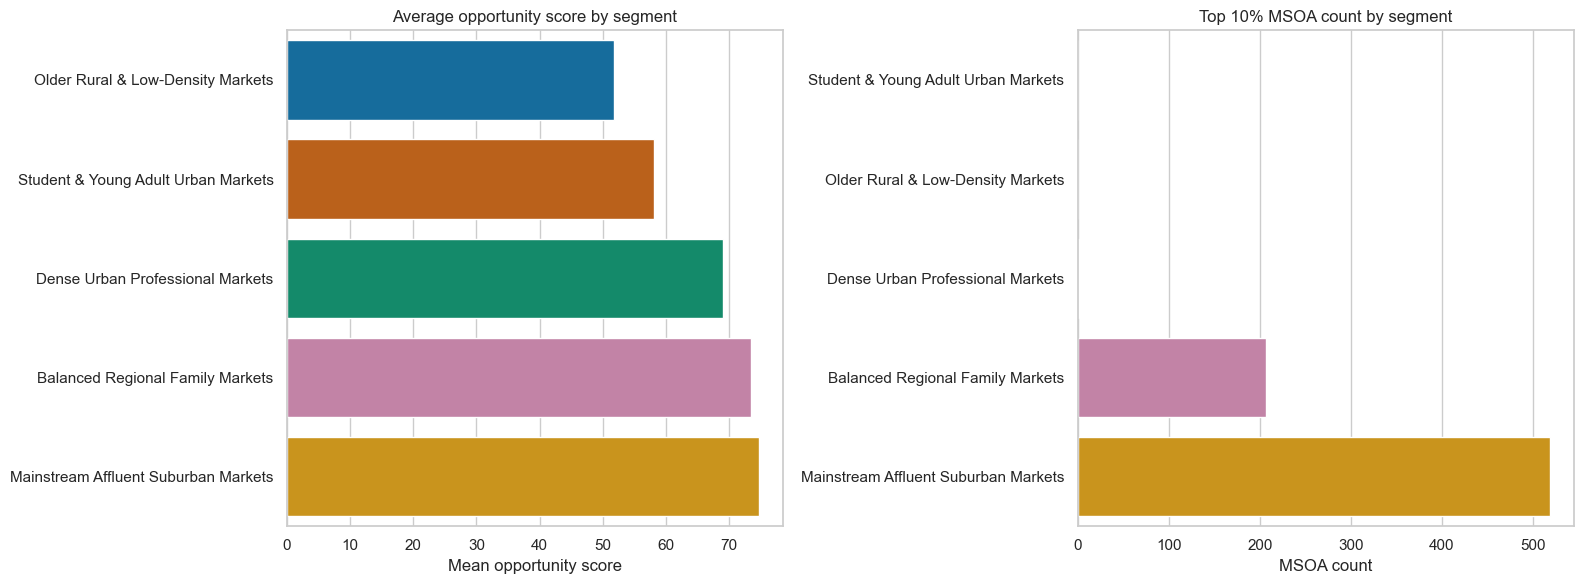

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

segment_plot = segment_opportunity_summary.sort_values("mean_opportunity_score", ascending=True)
segment_palette = dict(zip(segment_plot["segment_label"], PALETTE[: len(segment_plot)]))
sns.barplot(
    data=segment_plot,
    x="mean_opportunity_score",
    y="segment_label",
    hue="segment_label",
    palette=segment_palette,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Average opportunity score by segment")
axes[0].set_xlabel("Mean opportunity score")
axes[0].set_ylabel("")

sns.barplot(
    data=segment_opportunity_summary.sort_values("top_10_msoas", ascending=True),
    x="top_10_msoas",
    y="segment_label",
    hue="segment_label",
    palette=segment_palette,
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Top 10% MSOA count by segment")
axes[1].set_xlabel("MSOA count")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### Insight Interpretation for the Business Slide

The strongest opportunity is clearly family-led. Mainstream Affluent Suburban Markets and Balanced Regional Family Markets make up almost all top-ranked MSOAs, so they should be the core audience for the first wave of media investment.

The most attractive places are not single isolated MSOAs; they form practical local clusters. The top-ranked area table can be translated directly into regional media buying, CRM tests and attraction-specific campaign planning.

At attraction level, the strongest activation opportunities are concentrated around specific family propositions such as LEGOLAND Windsor Resort, SEA LIFE Manchester, Shrek's Adventure! London, Chessington World of Adventures Resort, SEA LIFE Birmingham and Cadbury World. This is the better level for campaign planning because it avoids overstating SEA LIFE purely because there are multiple SEA LIFE locations in the dataset.

At category level, the strategic story is still useful: Family Discovery Attraction and Family Theme Park propositions account for most top-ranked opportunities. Use the category roll-up to explain the type of proposition Merlin should prioritise, and the attraction-level table to decide where to activate.

Urban icon and young-adult propositions still matter, but they should be treated as more selective activation plays. They work best where proximity and city context are strong, rather than as the main nationwide opportunity engine.

### 6.5 What Should Merlin Activate First?

In [15]:
top_10_total = int(scored["top_10_opportunity_flag"].sum())
family_segments = ["Mainstream Affluent Suburban Markets", "Balanced Regional Family Markets"]
family_top_10 = int(segment_opportunity_summary.loc[segment_opportunity_summary["segment_label"].isin(family_segments), "top_10_msoas"].sum())
family_top_10_share = family_top_10 / top_10_total if top_10_total else 0

cluster_top_10 = int(scored.loc[scored["top_10_opportunity_flag"], "cluster_marketing_flag"].sum())
annual_pass_top_10 = int(scored.loc[scored["top_10_opportunity_flag"], "annual_pass_repeat_visit_flag"].sum())
short_break_top_10 = int(scored.loc[scored["top_10_opportunity_flag"], "short_break_opportunity_flag"].sum())

activation_recommendations = pd.DataFrame(
    [
        {
            "activation_priority": 1,
            "target_opportunity": "Family-led suburban and regional markets",
            "evidence": f"{family_top_10:,} of {top_10_total:,} top-10% MSOAs ({family_top_10_share:.0%}) sit in the two strongest family/suburban segments.",
            "recommended_merlin_focus": "LEGOLAND, Chessington, SEA LIFE, Shrek's Adventure and Cadbury World",
            "recommended_activation": "Prioritise annual pass, family day-out and short-break messaging around the top area clusters.",
        },
        {
            "activation_priority": 2,
            "target_opportunity": "Multi-attraction cluster markets",
            "evidence": f"{cluster_top_10:,} top-10% MSOAs have at least two Merlin attractions within 30 miles.",
            "recommended_merlin_focus": "Clustered portfolios and nearby attraction combinations",
            "recommended_activation": "Use cross-sell, CRM, annual pass and bundle messaging where multiple attractions are accessible.",
        },
        {
            "activation_priority": 3,
            "target_opportunity": "Annual pass markets",
            "evidence": f"{annual_pass_top_10:,} top-10% MSOAs are within 30 miles of the recommended attraction.",
            "recommended_merlin_focus": "Attractions with strong local catchments",
            "recommended_activation": "Promote annual pass value and in-attraction lifetime-value upsell opportunities.",
        },
        {
            "activation_priority": 4,
            "target_opportunity": "Short-break markets",
            "evidence": f"{short_break_top_10:,} top-10% MSOAs meet the family/affluence and overnight-distance rules.",
            "recommended_merlin_focus": "Resort, theme park and heritage-led destination trips",
            "recommended_activation": "Promote overnight stays, packages and premium family occasions where distance supports a short break.",
        },
    ]
)

activation_recommendations

,activation_priority,target_opportunity,evidence,recommended_merlin_focus,recommended_activation
0,1,Family-led suburban and regional markets,726 of 727 top-10% MSOAs (100%) sit in the two strongest family/suburban segments.,"LEGOLAND, Chessington, SEA LIFE, Shrek's Adventure and Cadbury World","Prioritise annual pass, family day-out and short-break messaging around the top area clusters."
1,2,Multi-attraction cluster markets,365 top-10% MSOAs have at least two Merlin attractions within 30 miles.,Clustered portfolios and nearby attraction combinations,"Use cross-sell, CRM, annual pass and bundle messaging where multiple attractions are accessible."
2,3,Annual pass markets,462 top-10% MSOAs are within 30 miles of the recommended attraction.,Attractions with strong local catchments,Promote annual pass value and in-attraction lifetime-value upsell opportunities.
3,4,Short-break markets,35 top-10% MSOAs meet the family/affluence and overnight-distance rules.,"Resort, theme park and heritage-led destination trips","Promote overnight stays, packages and premium family occasions where distance supports a short break."


## 7. Export Opportunity Outputs

Keep the export set deliberately small. The notebook writes only the files most useful for handover and interview submission:

- `merlin_key_recommendation_output.csv`: concise recommendation output with the key fields requested for decision-making
- `msoa_layer_2_opportunity_scores.csv`: full scored MSOA dataset for audit, modelling detail, and future opportunity scoring
- `msoa_layer_2_top_opportunity_msoas.csv`: top 250 MSOA shortlist for presentation and stakeholder review

In [16]:
output_columns = [
    "geo_code",
    "geo_name",
    "country",
    "latitude",
    "longitude",
    "segment_id",
    "segment_label",
    "overall_opportunity_score",
    "opportunity_rank",
    "opportunity_percentile",
    "market_size_score",
    "segment_priority_score",
    "recommended_attraction_alignment_score",
    "segment_category_fit_score",
    "recommended_attraction_focus",
    "recommended_attraction_name",
    "recommended_attraction_brand",
    "recommended_attraction_category",
    "recommended_attraction_distance_miles",
    "nearest_merlin_attraction",
    "nearest_merlin_brand",
    "nearest_merlin_category",
    "nearest_merlin_distance_miles",
    "recommended_product_focus",
    "recommended_commercial_play",
    "commercial_play_rationale",
    "recommended_activation",
    "annual_pass_repeat_visit_flag",
    "cluster_marketing_flag",
    "short_break_opportunity_flag",
    "merlin_attractions_within_30_miles",
    "merlin_attraction_cluster_names_30_miles",
    "illustrative_revenue_opportunity_1pct_gbp",
    "revenue_per_visitor_assumption_gbp",
    "penetration_rate_assumption",
    "key_contributing_driver",
    "assumptions_flag",
    "total_population",
    "children_count_0_14",
    "young_adult_count_15_24",
    "core_family_adult_count_25_44",
    "midlife_adult_count_45_64",
    "older_adult_count_65_plus",
    "total_households",
    "households_with_dependent_children",
    "households_deprived",
    "households_not_deprived",
    "households_no_car_or_van",
    "households_with_car_or_van",
    "residents_social_grade_ab_c1",
    "children_share_0_14",
    "young_adult_share_15_24",
    "core_family_adult_share_25_44",
    "midlife_adult_share_45_64",
    "older_adult_share_65_plus",
    "family_household_share",
    "deprived_household_share",
    "not_deprived_household_share",
    "car_access_household_share",
    "population_density_per_sq_km",
    "ab_c1_social_grade_share",
]

opportunity_export = scored[output_columns].copy().sort_values("opportunity_rank")

key_recommendation_columns = [
    "geo_code",
    "geo_name",
    "latitude",
    "longitude",
    "segment_id",
    "segment_label",
    "overall_opportunity_score",
    "opportunity_rank",
    "key_contributing_driver",
    "recommended_attraction_name",
    "recommended_product_focus",
    "recommended_commercial_play",
    "illustrative_revenue_opportunity_1pct_gbp",
]
key_recommendation_output = opportunity_export[key_recommendation_columns].copy()

TOP_N_EXPORT = 250
top_opportunities = opportunity_export.head(TOP_N_EXPORT).copy()

opportunity_export.to_csv(OPPORTUNITY_OUTPUT_PATH, index=False)
top_opportunities.to_csv(TOP_OPPORTUNITY_OUTPUT_PATH, index=False)
key_recommendation_output.to_csv(KEY_RECOMMENDATION_OUTPUT_PATH, index=False)

print(f"Saved full MSOA opportunity output: {OPPORTUNITY_OUTPUT_PATH} ({opportunity_export.shape[0]:,} rows)")
print(f"Saved top opportunities: {TOP_OPPORTUNITY_OUTPUT_PATH} ({top_opportunities.shape[0]:,} rows)")
print(f"Saved key recommendation output: {KEY_RECOMMENDATION_OUTPUT_PATH} ({key_recommendation_output.shape[0]:,} rows)")

key_recommendation_output.head(10)

Saved full MSOA opportunity output: /Users/ChanB01/GitHub/uk-demographic-clustering/data/output/msoa_layer_2_opportunity_scores.csv (7,264 rows)
Saved top opportunities: /Users/ChanB01/GitHub/uk-demographic-clustering/data/output/msoa_layer_2_top_opportunity_msoas.csv (250 rows)
Saved key recommendation output: /Users/ChanB01/GitHub/uk-demographic-clustering/data/output/merlin_key_recommendation_output.csv (7,264 rows)


,geo_code,geo_name,latitude,longitude,segment_id,segment_label,overall_opportunity_score,opportunity_rank,key_contributing_driver,recommended_attraction_name,recommended_product_focus,recommended_commercial_play,illustrative_revenue_opportunity_1pct_gbp
3203,E02003353,Bracknell Forest 002,51.43602,-0.763020,4,Mainstream Affluent Suburban Markets,97.7,1,large local market,LEGOLAND Windsor Resort,Multi-attraction cluster marketing,Multi-attraction cluster marketing,3899
569,E02000601,Kingston upon Thames 004,51.41714,-0.298440,4,Mainstream Affluent Suburban Markets,97.6,2,large local market,Chessington World of Adventures Resort,Multi-attraction cluster marketing,Multi-attraction cluster marketing,3835
6585,E02006837,Epsom and Ewell 010,51.34441,-0.238040,4,Mainstream Affluent Suburban Markets,97.6,3,large local market,Chessington World of Adventures Resort,Multi-attraction cluster marketing,Multi-attraction cluster marketing,3797
3298,E02003450,Wokingham 012,51.41607,-0.937690,4,Mainstream Affluent Suburban Markets,97.5,4,large local market,LEGOLAND Windsor Resort,Multi-attraction cluster marketing,Multi-attraction cluster marketing,4244
6154,E02006399,Runnymede 007,51.37477,-0.503170,4,Mainstream Affluent Suburban Markets,97.5,5,large local market,Chessington World of Adventures Resort,Multi-attraction cluster marketing,Multi-attraction cluster marketing,3947
6628,E02006882,Harrow 033,51.59156,-0.313320,4,Mainstream Affluent Suburban Markets,97.3,6,large local market,Chessington World of Adventures Resort,Multi-attraction cluster marketing,Multi-attraction cluster marketing,4622
6668,E02006925,Redbridge 036,51.58409,0.053548,4,Mainstream Affluent Suburban Markets,97.3,7,large local market,Shrek's Adventure! London,Multi-attraction cluster marketing,Multi-attraction cluster marketing,4630
741,E02000787,Richmond upon Thames 004,51.46775,-0.285110,4,Mainstream Affluent Suburban Markets,97.2,8,large local market,Chessington World of Adventures Resort,Multi-attraction cluster marketing,Multi-attraction cluster marketing,3877
3529,E02003688,Buckinghamshire 053,51.60788,-0.637940,4,Mainstream Affluent Suburban Markets,97.1,9,large local market,LEGOLAND Windsor Resort,Multi-attraction cluster marketing,Multi-attraction cluster marketing,3920
5001,E02005204,Fylde 002,53.78466,-2.897340,4,Mainstream Affluent Suburban Markets,96.9,10,large local market,SEA LIFE Blackpool,Annual pass,Annual pass,4022


## 8. Assumptions, Limitations and Next Steps

This opportunity score should be presented as a prioritisation index, not a demand forecast. It is designed to rank where Merlin should investigate, test and activate first.

Main assumptions and limitations:

- The score uses public demographic and geographic data only. It does not include Merlin bookings, passholder records, CRM engagement, ticket yield, media spend, web demand or historic conversion.
- Segment priority and attraction-category fit are judgement-based. They are intentionally simple for stakeholder communication, but should be calibrated with Merlin customer and revenue data when available.
- Distance is measured from MSOA centroid to attraction coordinates using straight-line geography. A production version should use drive time, public transport time and catchment overlap.
- AB/C1 share, deprivation and household composition are useful proxies, but they are not the same as disposable income, leisure intent or actual propensity to visit Merlin.
- Competitor attractions, tourism flows, accommodation supply, school-holiday timing and local media costs are not included. These could change the commercial priority of some areas.
- The recommended attraction is the best modelled Merlin proposition for that MSOA, after combining segment-category fit and distance to that specific attraction. It is not necessarily the nearest Merlin attraction.

Recommended next stage:

Use this output as a shortlist for validation. The most valuable next step would be to overlay internal Merlin customer penetration, revenue, product ownership, campaign response and drive-time data. That would turn this public-data opportunity index into a calibrated growth and media-prioritisation model.